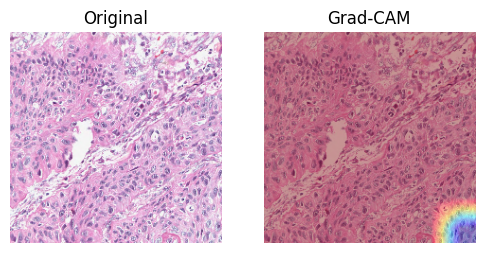

In [3]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load model architecture + weights
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(224,224,3)
)
base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(base_model.input, output)
model.load_weights("../models/efficientnet_histo_weights")

last_conv_layer = base_model.get_layer("top_conv")

def gradcam(img_array):
    grad_model = tf.keras.models.Model(
        [model.inputs], [last_conv_layer.output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap = np.maximum(heatmap[0], 0) / (np.max(heatmap[0]) + 1e-8)
    return heatmap

# Test on one image
img_path = r"E:\oral-cancer-project\data\histo_split\test\cancer\1009009_roi_1009009_r17c0.png"
img = cv2.imread(img_path)
if img is None:
    raise ValueError(f"Image not found: {img_path}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))
img_arr = np.expand_dims(img/255.0, axis=0)

heatmap = gradcam(img_arr)
heatmap = cv2.resize(heatmap, (224,224))
overlay = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)
superimposed = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(img); plt.axis('off')
plt.subplot(1,2,2); plt.title("Grad-CAM"); plt.imshow(superimposed); plt.axis('off')
plt.show()
